In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from PIL import Image
from scipy.sparse import csr_matrix
import numpy as np
import tensorflow as tf
import pickle as pkl
from skimage import measure
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model


I0000 00:00:1778657378.523819   15432 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778657378.766684   15432 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778657379.983101   15432 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Malignant or Benign?

### Functions for reading, cropping and resizing images:

In [2]:
from PIL import Image
import numpy as np

def load_crop_resize_image(image_path, s, mode="RGB"):
    """
    Load an image with PIL, center-crop it to a square using
    min(width, height), resize to s x s, and select channels.

    Parameters
    ----------
    image_path : str
        Path to the image.
    
    s : int
        Output image size (s x s).
    
    mode : str
        One of:
        - "R"   : red channel
        - "G"   : green channel
        - "B"   : blue channel
        - "RGB" : full RGB image
        - "L"   : grayscale

    Returns
    -------
    np.ndarray
        Processed image as numpy array.
    """

    # Open image
    img = Image.open(image_path).convert("RGB")

    width, height = img.size

    # Square crop size
    crop_size = min(width, height)

    # Center crop coordinates
    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    # Crop
    img = img.crop((left, top, right, bottom))

    # Resize
    img = img.resize((s, s), Image.Resampling.LANCZOS)

    # Channel selection
    mode = mode.upper()

    if mode == "RGB":
        return np.array(img)

    elif mode in ["R", "G", "B"]:
        channel_index = {"R": 0, "G": 1, "B": 2}[mode]
        return np.array(img)[:, :, channel_index]

    elif mode == "L":
        return np.array(img.convert("L"))

    else:
        raise ValueError("mode must be one of: 'R', 'G', 'B', 'RGB', 'L'")

### Function for image contour detection:

In [3]:
import numpy as np
from skimage import measure


def contour_mask(img_np, threshold=None):
    """
    Returns a binary contour mask.

    Parameters
    ----------
    img_np : np.ndarray
        Can be:
        - RGB image: (H, W, 3)
        - Single channel image: (H, W)

    threshold : float or None

    Returns
    -------
    np.ndarray of bool
    """

    # RGB image
    if img_np.ndim == 3:
        gray = (
            0.299 * img_np[:, :, 0] +
            0.587 * img_np[:, :, 1] +
            0.114 * img_np[:, :, 2]
        )

    # Already grayscale / single-channel
    elif img_np.ndim == 2:
        gray = img_np.astype(np.float32)

    else:
        raise ValueError("Unsupported image shape")

    # Threshold
    if threshold is None:
        threshold = gray.mean()

    binary = gray < threshold

    # Find contours
    contours = measure.find_contours(binary, level=0.5)

    # Output mask
    mask = np.zeros(binary.shape, dtype=bool)

    # Draw contours
    for contour in contours:
        coords = np.round(contour).astype(int)

        for y, x in coords:
            if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
                mask[y, x] = True

    return mask

# Reading the files for test from external data repository (we will use it later):

In [4]:
BH=list(set(glob.glob("BreakHis/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/40X/*/**")))

In [5]:
y_outer_test=np.array([1 if i.split("/")[6]=="malignant" else 0 for i in BH])

In [6]:
outer_test=np.array([load_crop_resize_image(i,224,"L") for i in BH])

In [7]:
#outer_test=np.array([load_crop_resize_image(i,224,"RGB") for i in BH])

# Reading data for training our models:

### Reading folds information:

In [8]:
folds=pd.read_csv('BreakHis_large/Folds.csv')

### Defining multiclass information: 

In [9]:
folds["multiclass"]=[i.split("/")[5] for i in  folds.filename]

### Defining binary classification information:

In [10]:
folds["target"]=[0 if "benign" in i else 1 for i in folds.filename]

In [11]:
class_dict=dict(enumerate(folds.multiclass.unique()))
class_dict={class_dict[i]:i for i in class_dict}
folds["multiclass_target"]=[class_dict[i] for i in folds.multiclass]

### Restricting data to 40X zoom scans:

In [12]:
folds=folds[folds.mag==40]

In [13]:
class_dict=dict(enumerate(folds.multiclass.unique()))

### Reading train and test files:

In [14]:
train_files=list(set(["BreakHis_large/BreaKHis_v1/"+i for i in folds[folds.grp=="train"].filename.tolist()]))

In [15]:
y_train=np.array([1 if "malignant" in i else 0 for i in train_files])

In [16]:
test_files=list(set(["BreakHis_large/BreaKHis_v1/"+i for i in folds[folds.grp=="test"].filename.tolist()]))

In [17]:
y_test=np.array([1 if "malignant" in i else 0 for i in test_files])

In [18]:
#train_files=list(set(["BreakHis_large/BreaKHis_v1/"+i for i in folds[folds.grp=="train"].filename.tolist()]))
#y_train=folds[folds.grp=="train"].target.tolist()
#y_multi_train=folds[folds.grp=="train"].multiclass_target.tolist()
#test_files=["BreakHis_large/BreaKHis_v1/"+i for i in folds[folds.grp=="test"].filename.tolist()]
#y_test=folds[folds.grp=="test"].target.tolist()
#y_multi_test=folds[folds.grp=="test"].multiclass_target.tolist()

### Total Malignant:

In [19]:
list(y_train).count(1)

1370

### Total Benign:

In [19]:
list(y_train).count(0)

625

### Hmm, it looks like we have a class inbalance here... Let´s move on and see what happens with the models.

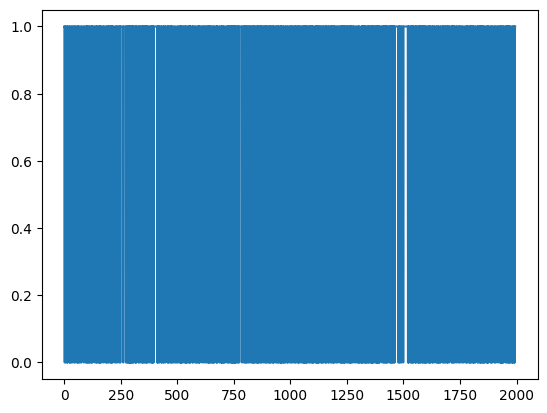

In [20]:
plt.plot(y_train)

### It looks like we will have a bias in our labels. Let's randomize the data with a fixed random seed:

In [28]:
import numpy as np
np.random.seed(40)
# Train
train_idx = np.random.permutation(len(train_files))

train_files = np.array(train_files)[train_idx]
y_train = np.array(y_train)[train_idx]
#y_multi_train = np.array(y_multi_train)[train_idx]

# Test
test_idx = np.random.permutation(len(test_files))

test_files = np.array(test_files)[test_idx]
y_test = np.array(y_test)[test_idx]
#y_multi_test = np.array(y_multi_test)[test_idx]

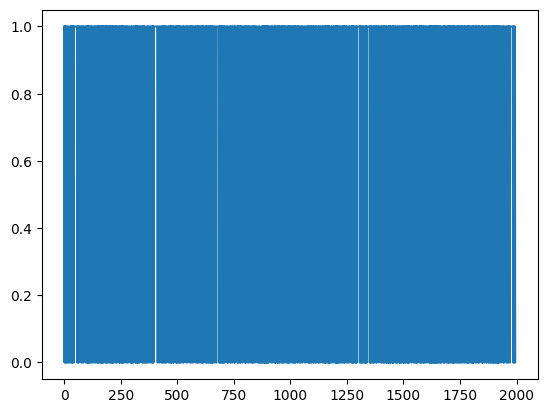

In [29]:
plt.plot(y_train)

### Reading the train data and validation/train data (X and X_train_val). We are calling them this way to do not mix the variables of train, test and validation splits afterwards:

$$\textcolor{red}{\text{WARNING!!!}}$$
The following commands will take a while! Be pacient!

In [30]:
X=np.array([load_crop_resize_image(i,224,"L") for i in train_files])

In [31]:
X.shape

(1995, 224, 224)

In [25]:
#X=np.array([load_crop_resize_image(i,224,"RGB") for i in train_files])

### Saving the X file:

In [26]:
#with open("X.pkl", "wb") as f:
#    pkl.dump(X, f)

In [27]:
#X_train_val=np.array([contour_mask(load_crop_resize_image(i,224,"RGB")) for i in test_files])

### Saving the X_train_val file:

In [28]:
#with open("X_train_val.pkl", "wb") as f:
#    pkl.dump(X_train_val, f)

### Reading back the files:

In [29]:
#with open("X.pkl", "rb") as f:
#    X = pkl.load(f).astype(np.int8)

In [30]:
#with open("X_train_val.pkl", "rb") as f:
#    X_train_val = pkl.load(f).astype(np.int8)

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


# Train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


### Creating a function for creating a deep learning model:

All the models generated have the structure:

1. **Input layer:** A 224x224 numpy array of type np.uint8 with the image contour information
2. **Output:** A probability value (a value in a rage [0,1]) for the class 1 (malignant)


# Original Model:

I0000 00:00:1778596630.813303    8796 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

I0000 00:00:1778596638.447521    9243 cuda_dnn.cc:461] Loaded cuDNN version 92101


63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step


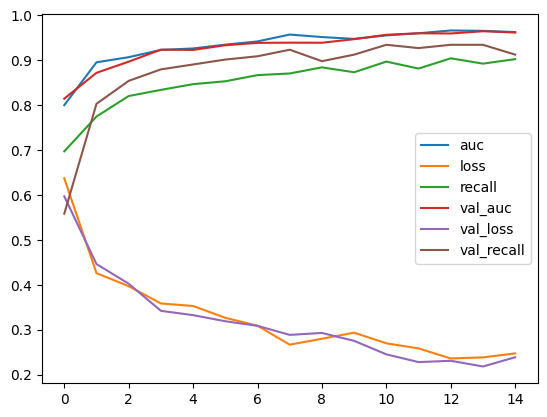

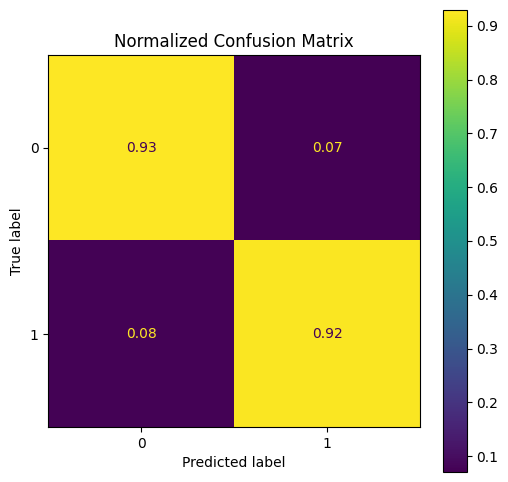

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(256, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Large_model_cw_v6.keras")

# Original Model without class weight

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_52 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_17 (Sequential)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_34 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_17 (Add)                    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_35 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step


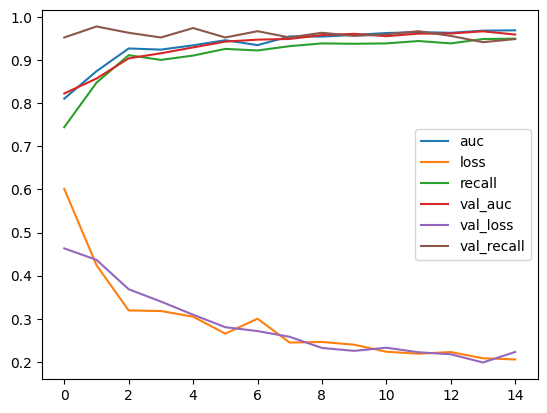

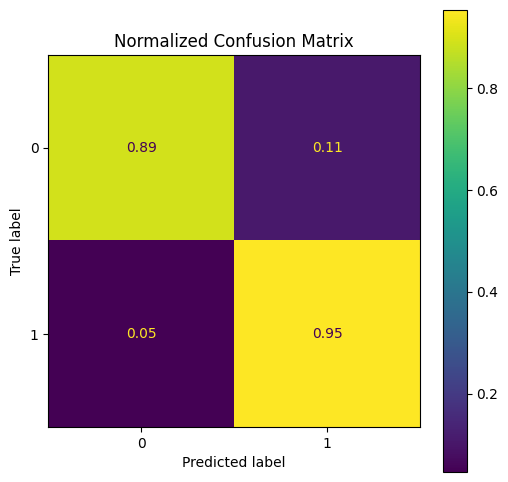

In [98]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(256, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Large_model_v6.keras")

# First refined model with class weights

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_55 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_18 (Sequential)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_36 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_18 (Add)                    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_37 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step


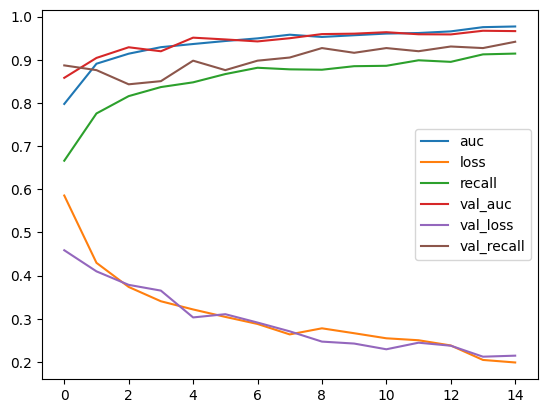

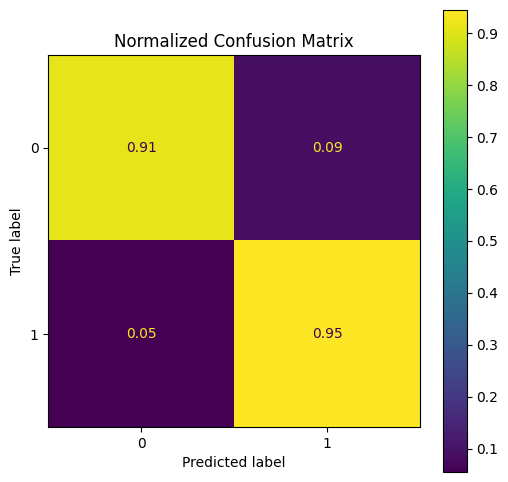

In [99]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_cw_v6.keras")

# First refined model without class weights

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

I0000 00:00:1778661089.815521   44603 cuda_dnn.cc:461] Loaded cuDNN version 92101


63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step


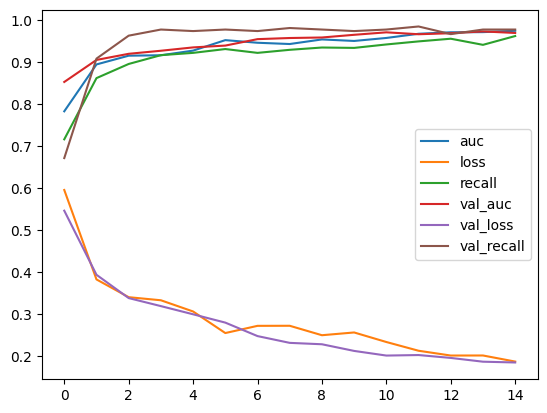

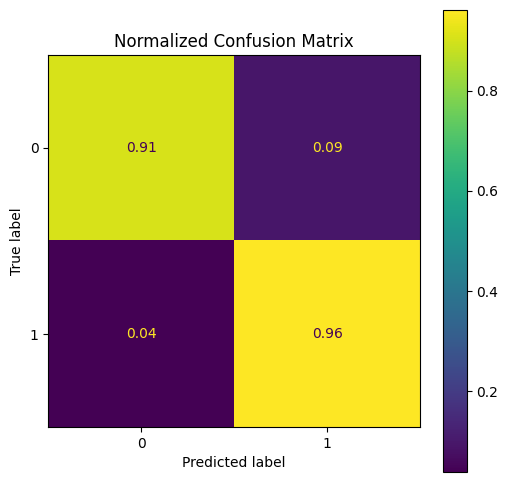

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

#model.save("Refined_model_v6.keras")

# Second refined model with class weights

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_3 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,107,521 (27.11 MB)

 Trainable params: 67,841 (265.00 KB)

 Non-trainable params: 7,039,680 (26.85 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step


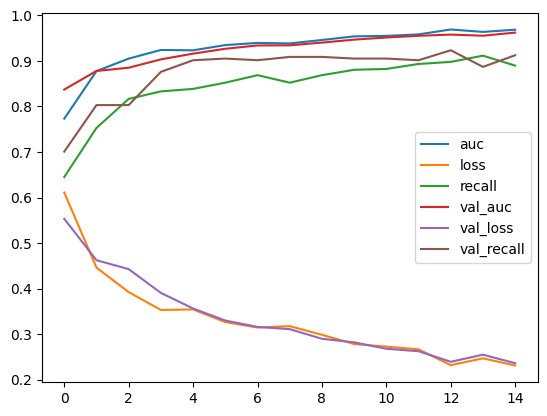

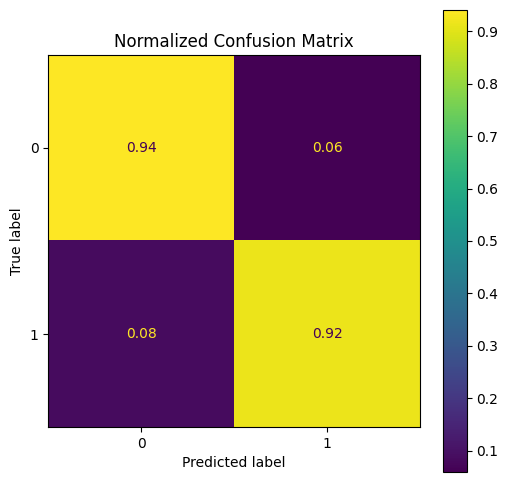

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_2_cw_v6.keras")

# Second Refinement without class weight

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,107,521 (27.11 MB)

 Trainable params: 67,841 (265.00 KB)

 Non-trainable params: 7,039,680 (26.85 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step


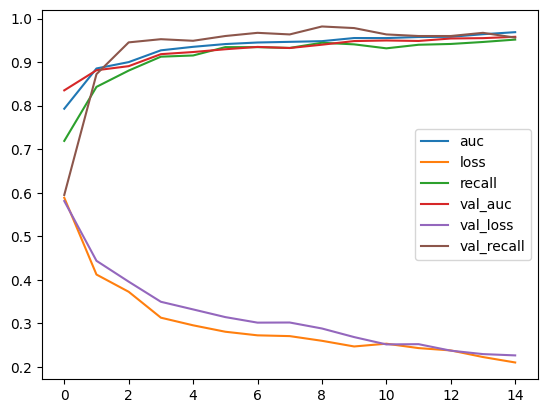

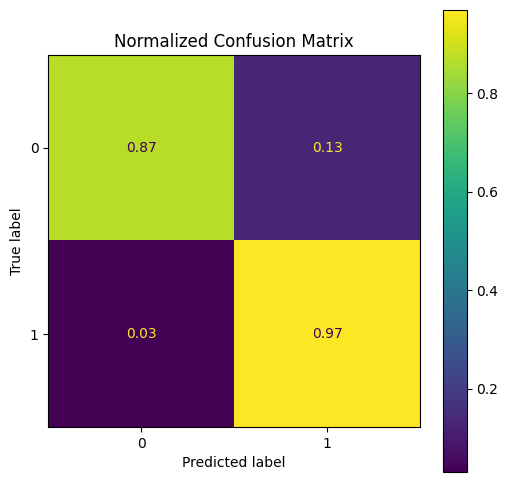

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
      #  class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_2_v6.keras")

# Third refinement with class weight

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_8 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_4 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_9 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,074,561 (26.99 MB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 7,039,616 (26.85 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step


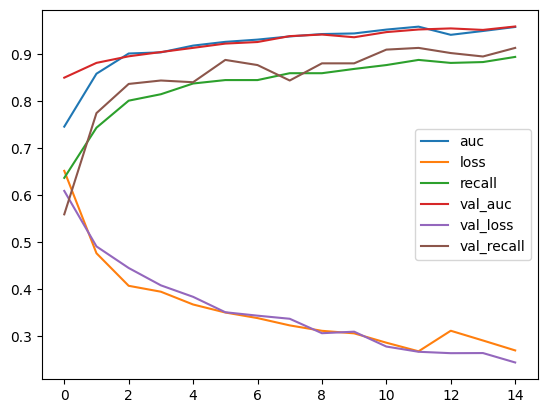

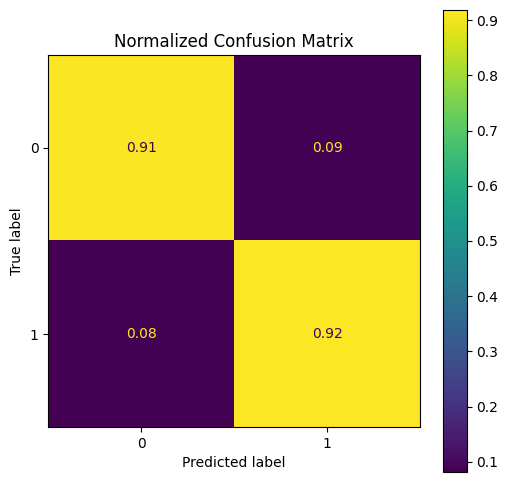

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_3_cw_v6.keras")

# Third Refinment without class weight

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_10 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_5 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_11 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,074,561 (26.99 MB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 7,039,616 (26.85 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step


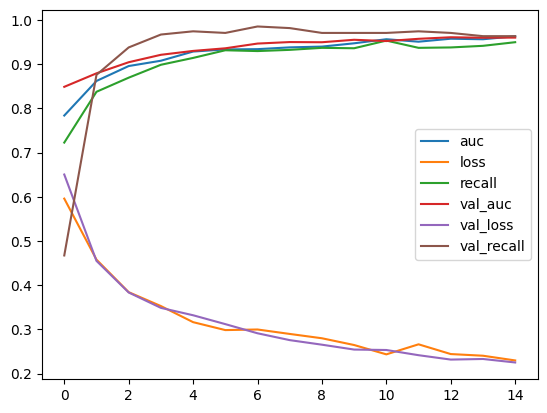

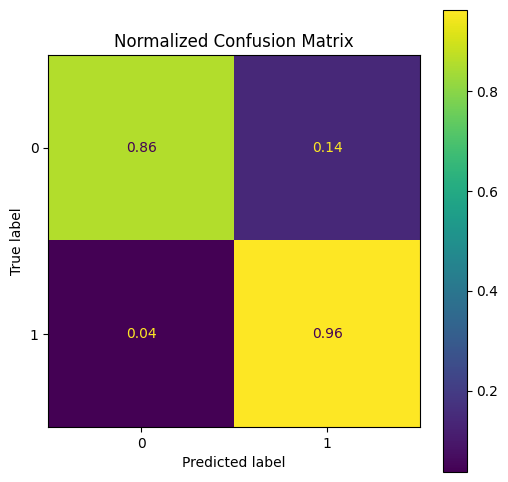

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_3_v6.keras")

In [ ]:
# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)


<Axes: >

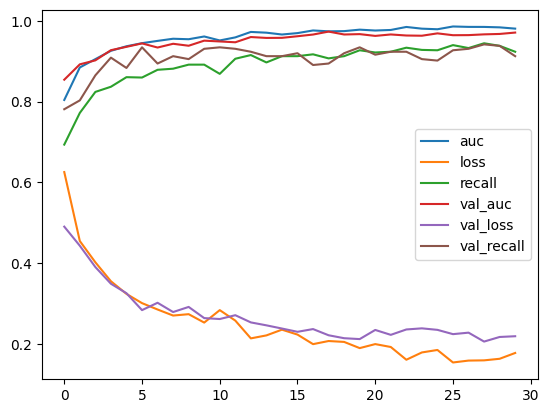

In [89]:
pd.DataFrame(history.history).plot()

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step


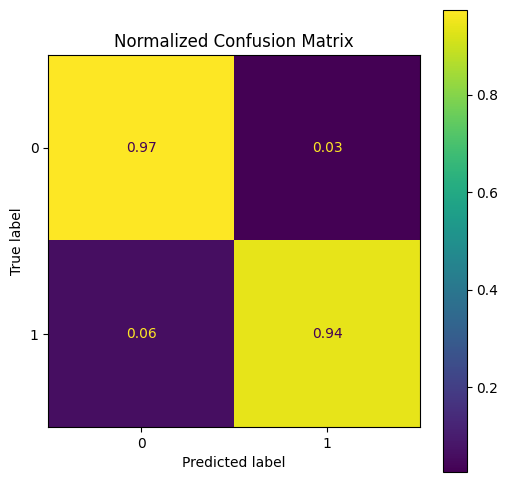

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
 #   layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
#x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.4)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()




Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_3 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,042,625 (26.87 MB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [61]:
# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
    class_weight=class_weight,
    verbose=False
)


In [50]:
# =========================================================
# INITIAL TRAINING
# =========================================================

history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        verbose=False,
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - auc: 0.6056 - loss: 0.7255 - recall: 0.7454 - val_auc: 0.7595 - val_loss: 0.5410 - val_recall: 0.9526
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - auc: 0.7416 - loss: 0.5616 - recall: 0.8613 - val_auc: 0.8276 - val_loss: 0.4863 - val_recall: 0.9380
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - auc: 0.7963 - loss: 0.5019 - recall: 0.8777 - val_auc: 0.8592 - val_loss: 0.4533 - val_recall: 0.9453
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - auc: 0.8369 - loss: 0.4505 - recall: 0.8960 - val_auc: 0.8761 - val_loss: 0.4296 - val_recall: 0.9635
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - auc: 0.8566 - loss: 0.4273 - recall: 0.8969 - val_auc: 0.8822 - val_loss: 0.4117 - val_recall: 0.9562
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - auc: 0.8680 - loss: 0.4097 - recall: 0.9243 - val_auc: 0.8886 - val_loss: 0.3994 - val_recall: 0.9526
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - auc: 0.87

In [56]:
# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
    class_weight=class_weight,
    verbose=False
)


<Axes: >

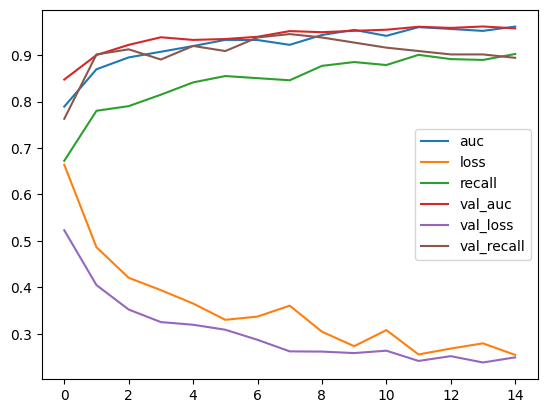

In [62]:
pd.DataFrame(history.history).plot()

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()




Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

In [31]:
# =========================================================
# INITIAL TRAINING
# =========================================================

history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
)


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - auc: 0.8609 - loss: 0.5359 - recall: 0.7792 - val_auc: 0.9495 - val_loss: 0.3593 - val_recall: 0.9927
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - auc: 0.9300 - loss: 0.3338 - recall: 0.8878 - val_auc: 0.9739 - val_loss: 0.3011 - val_recall: 0.9927
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - auc: 0.9495 - loss: 0.2765 - recall: 0.9024 - val_auc: 0.9688 - val_loss: 0.3150 - val_recall: 0.9927
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - auc: 0.9526 - loss: 0.2540 - recall: 0.9297 - val_auc: 0.9746 - val_loss: 0.3050 - val_recall: 0.9964
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - auc: 0.9609 - loss: 0.2327 - recall: 0.9361 - val_auc: 0.9808 - val_loss: 0.2472 - val_recall: 0.9964
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - auc: 0.9687 - loss: 0.1993 - recall: 0.9480 - val_auc: 0.9836 - val_loss: 0.2177 - val_recall: 0.9964
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - auc: 0.96

In [58]:
from sklearn.metrics import classification_report
import numpy as np

# =========================================================
# PREDICTIONS
# =========================================================

# Predict probabilities
y_prob = model.predict(X_val).ravel()

# Convert probabilities to binary labels
y_pred = (y_prob >= 0.5).astype(int)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_val.astype(int),
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step
              precision    recall  f1-score   support

      Benign       0.70      0.88      0.78       125
   Malignant       0.94      0.82      0.88       274

    accuracy                           0.84       399
   macro avg       0.82      0.85      0.83       399
weighted avg       0.86      0.84      0.85       399



In [79]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
#x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.2)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()




Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_18 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_9 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_19 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,345 (27.35 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 7,037,760 (26.85 MB)

In [80]:
# =========================================================
# INITIAL TRAINING
# =========================================================

history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
    #class_weight=class_weight,
    verbose=False
)


In [81]:
from sklearn.metrics import classification_report
import numpy as np

# =========================================================
# PREDICTIONS
# =========================================================

# Predict probabilities
y_prob = model.predict(X_val).ravel()

# Convert probabilities to binary labels
y_pred = (y_prob >= 0.5).astype(int)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_val.astype(int),
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step
              precision    recall  f1-score   support

      Benign       0.76      0.85      0.80       125
   Malignant       0.93      0.88      0.90       274

    accuracy                           0.87       399
   macro avg       0.84      0.86      0.85       399
weighted avg       0.87      0.87      0.87       399



In [66]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
#x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(128, activation='relu')(x)

#x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.5)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()




Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_12 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_6 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_13 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [67]:
# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
    class_weight=class_weight,
    verbose=False
)


In [68]:
from sklearn.metrics import classification_report
import numpy as np

# =========================================================
# PREDICTIONS
# =========================================================

# Predict probabilities
y_prob = model.predict(X_val).ravel()

# Convert probabilities to binary labels
y_pred = (y_prob >= 0.5).astype(int)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_val.astype(int),
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step
              precision    recall  f1-score   support

      Benign       0.62      0.90      0.74       125
   Malignant       0.94      0.75      0.84       274

    accuracy                           0.80       399
   macro avg       0.78      0.83      0.79       399
weighted avg       0.84      0.80      0.80       399



<Axes: >

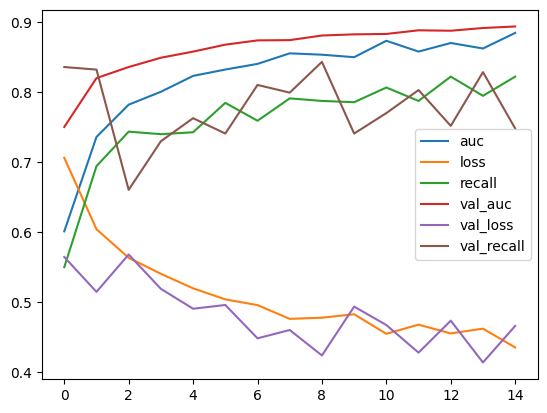

In [69]:
pd.DataFrame(history.history).plot()

In [50]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
#x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.4)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(128, activation='relu')(x)

#x = layers.BatchNormalization()(x)
#x = layers.Dropout(0.5)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()




Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_12 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_6 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_13 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [51]:
# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
    class_weight=class_weight,
)


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - auc: 0.7354 - loss: 0.6055 - recall: 0.6943 - val_auc: 0.8217 - val_loss: 0.5041 - val_recall: 0.8431
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - auc: 0.8894 - loss: 0.4559 - recall: 0.8221 - val_auc: 0.8993 - val_loss: 0.4151 - val_recall: 0.9015
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - auc: 0.9234 - loss: 0.3909 - recall: 0.8768 - val_auc: 0.9255 - val_loss: 0.3678 - val_recall: 0.9088
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - auc: 0.9319 - loss: 0.3610 - recall: 0.8777 - val_auc: 0.9408 - val_loss: 0.3201 - val_recall: 0.9380
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - auc: 0.9465 - loss: 0.3328 - recall: 0.8996 - val_auc: 0.9506 - val_loss: 0.2930 - val_recall: 0.9453
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - auc: 0.9560 - loss: 0.3049 - recall: 0.9106 - val_auc: 0.9547 - val_loss: 0.2804 - val_recall: 0.9380
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - auc: 0.96

<Axes: >

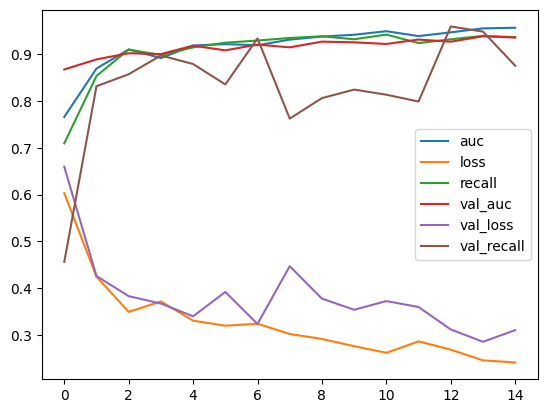

In [83]:
pd.DataFrame(history.history).plot()

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step


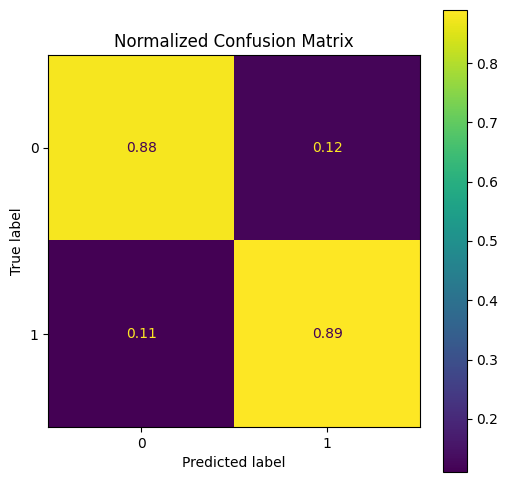

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step


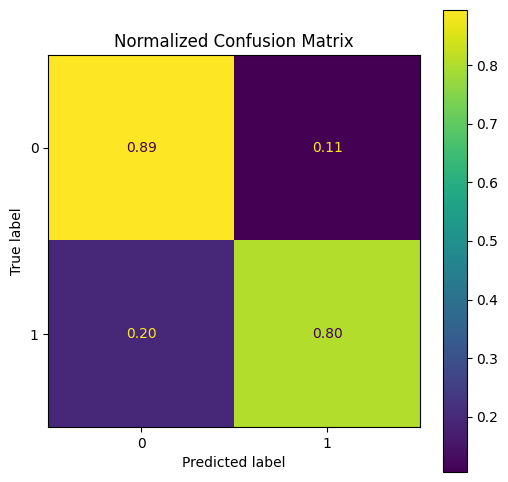

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

In [ ]:
# =========================================================
# FINE TUNING
# =========================================================

# Unfreeze last DenseNet layers
base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Recompile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Fine-tuning
fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

In [31]:
from tensorflow.keras import layers, models

def create_model(convs=[32, 64, 128, 256],
                 denses=[128],
                 denses_dropouts=[0.5]):
    """
    Creates and returns a configurable CNN model for binary image classification.

    Parameters
    ----------
    convs : list of int, optional
        Number of filters for each convolutional block.
        Each value creates:
            Conv2D(filters, 3x3, ReLU, padding='same')
            + MaxPooling2D(2x2)

        Default:
            [32, 64, 128, 256]

    denses : list of int, optional
        Number of neurons in each fully connected (Dense) layer.

        Default:
            [128]

    denses_dropouts : list of float, optional
        Dropout rates applied after each Dense layer.
        If the list is shorter than `denses`, remaining Dense layers
        will not use dropout.

        Example:
            denses=[256, 128]
            denses_dropouts=[0.5, 0.3]

        Default:
            [0.5]

    Returns
    -------
    tensorflow.keras.models.Sequential
        A compiled-ready Keras Sequential CNN model.

    Architecture
    ------------
    Input:
        (224, 224, 1) grayscale image

    Convolutional feature extractor:
        Repeated Conv2D + MaxPooling2D blocks

    Classifier:
        Flatten
        Dense layers (+ optional Dropout)

    Output:
        Dense(1, activation='sigmoid')

    Notes
    -----
    - Designed for binary classification problems.
    - Uses sigmoid activation in the output layer.
    - The model is NOT compiled inside this function.
    - Input images must have shape:
          (224, 224, 1)

    Example
    -------
    model = create_model(
        convs=[32, 64, 128],
        denses=[256, 128],
        denses_dropouts=[0.5, 0.3]
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    """

    model = models.Sequential()

    # Input
    model.add(layers.Input(shape=(224, 224, 1)))

    # Convolutional blocks
    for filters in convs:
        model.add(layers.Conv2D(filters, (3, 3),
                                activation='relu',
                                padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))

    # Flatten
    model.add(layers.Flatten())

    # Dense layers
    for i, units in enumerate(denses):
        model.add(layers.Dense(units, activation='relu'))

        if i < len(denses_dropouts):
            model.add(layers.Dropout(denses_dropouts[i]))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

We are going to test different models, starting by a complex model, and proposing other models by removing layers from the first model proposed:

### Testing parameters for 4 different models:

In [32]:
pars=[[[32,64,128,256],[128],[0.5]],[[32,64,32],[16],[0.5]],[[32,64],[16],[0.25]],[[64],[16],[0.25]]]

# Data train and test split:

In [33]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


# Train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


### Benchmarking the proposed models:

In [34]:
Sums=[]
Hists=[]
Reports=[]
counter=-1
for par in pars:
    counter+=1
    # Compile
    model=create_model(*par)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='roc_auc')
        ]
    )
    
    # Capture summary lines
    summary_lines = []

    model.summary(print_fn=lambda x: summary_lines.append(x))

    # Convert to DataFrame
    df_summary = pd.DataFrame(summary_lines, columns=["model_summary"])
    Sums.append(df_summary)
    

    
    history = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        verbose=0,
    
    )

    # Evaluation
    y_prob = model.predict(X_val).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    print("\nClassification Report:\n")
    cr=classification_report(y_val, y_pred)
    Reports.append(cr)
    print(cr)

    print("\nROC-AUC Score:")
    print(roc_auc_score(y_val, y_prob))
    Hists.append(history)
    model.save(f"Model_{counter}.keras")

I0000 00:00:1778569963.508551    9336 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


I0000 00:00:1778569964.937172   12622 service.cc:153] XLA service 0x7ac1280384f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778569964.937185   12622 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778569964.966864   12622 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778569965.150508   12622 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778569965.183613   12622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2714__.52
I0000 00:00:1778569972.207896   12622 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778569975.150654   12622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_271

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.38      0.39       125
           1       0.72      0.74      0.73       274

    accuracy                           0.63       399
   macro avg       0.56      0.56      0.56       399
weighted avg       0.62      0.63      0.62       399


ROC-AUC Score:
0.6022919708029197


I0000 00:00:1778570027.692030   12623 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12771__.43
I0000 00:00:1778570031.873408   12623 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12771__.43


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.27      0.32       125
           1       0.71      0.81      0.76       274

    accuracy                           0.64       399
   macro avg       0.55      0.54      0.54       399
weighted avg       0.61      0.64      0.62       399


ROC-AUC Score:
0.582029197080292


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.47      0.26      0.33       125
           1       0.72      0.87      0.79       274

    accuracy                           0.68       399
   macro avg       0.59      0.56      0.56       399
weighted avg       0.64      0.68      0.64       399


ROC-AUC Score:
0.6281167883211679


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       125
           1       0.69      1.00      0.81       274

    accuracy                           0.69       399
   macro avg       0.34      0.50      0.41       399
weighted avg       0.47      0.69      0.56       399


ROC-AUC Score:
0.5


/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

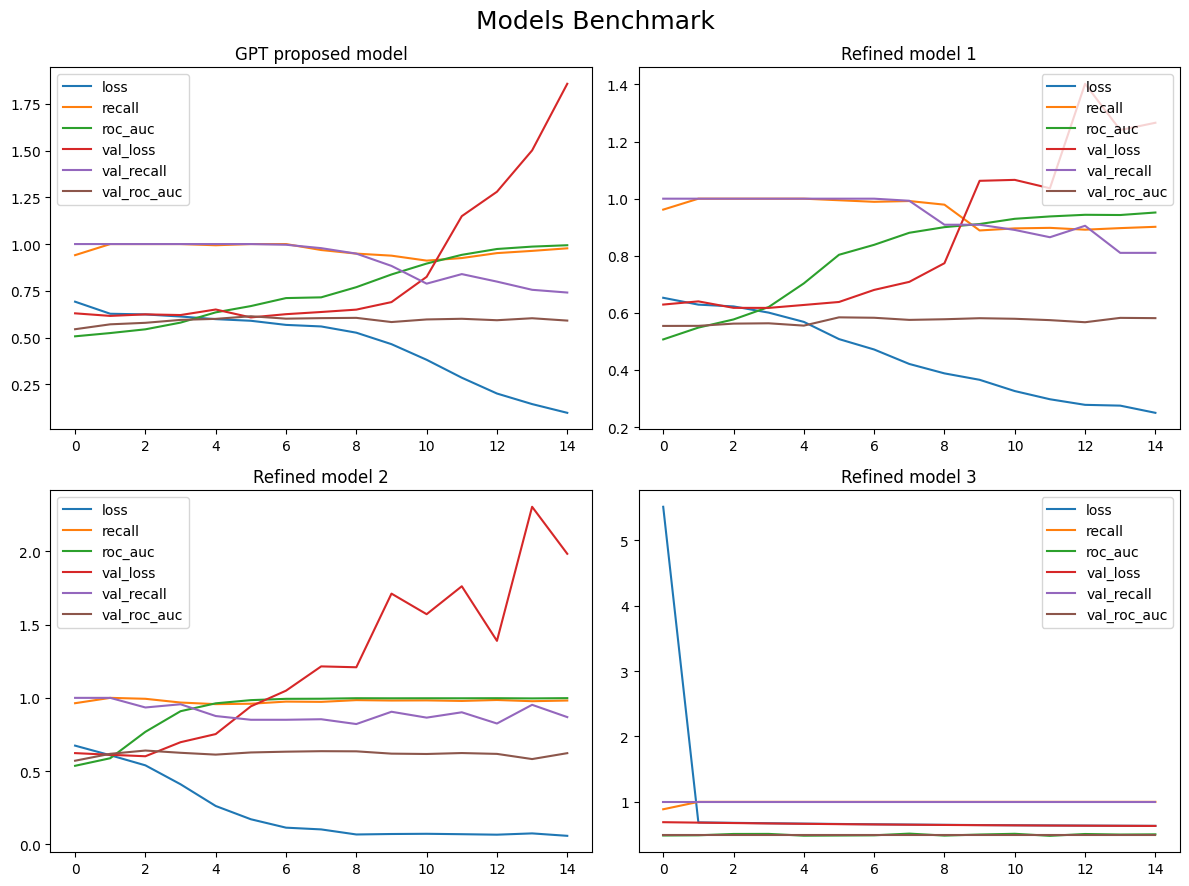

In [35]:

plt.figure(figsize=(12,9))
plt.suptitle("Models Benchmark",fontsize=18)
titles=["GPT proposed model", "Refined model 1", "Refined model 2", "Refined model 3"]
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    plt.title(titles[i])
    pd.DataFrame(Hists[i].history).plot(ax=ax)

plt.tight_layout()
plt.savefig("Image_Breast_Cancer_models_Benchmark.png",dpi=150,bbox_inches="tight")

In [36]:
# CNN model
opt_model = models.Sequential([

    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(1, activation='sigmoid')
])

# Compile
opt_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='roc_auc')
    ]
)

# Train
history = opt_model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=0,
    
)

# Evaluation
y_prob = opt_model.predict(X_val).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_val, y_prob))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.05      0.09       125
           1       0.70      0.99      0.82       274

    accuracy                           0.70       399
   macro avg       0.72      0.52      0.45       399
weighted avg       0.71      0.70      0.59       399


ROC-AUC Score:
0.5924233576642335


<Axes: >

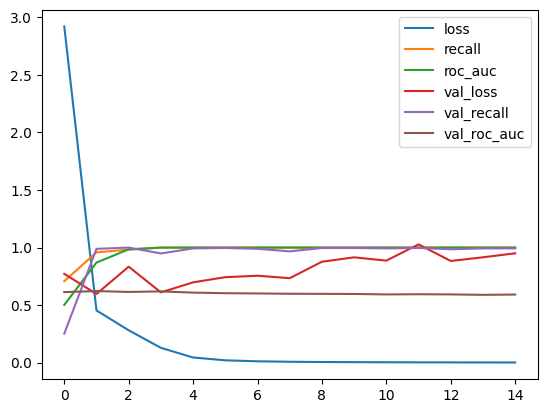

In [37]:
pd.DataFrame(opt_model.history.history).plot()

In [76]:
opt_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │       802,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,410,373 (9.19 MB)

 Trainable params: 803,457 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,606,916 (6.13 MB)

In [78]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │    12,845,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,537,189 (147.01 MB)

 Trainable params: 12,845,729 (49.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,691,460 (98.01 MB)

In [38]:
# CNN model
opt_model2 = models.Sequential([

    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(1, activation='sigmoid')
])

# Compile
opt_model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='roc_auc')
    ]
)

# Train
history = opt_model2.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=0,
    
)

# Evaluation
y_prob = opt_model2.predict(X_val).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_val, y_prob))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.09      0.15       125
           1       0.70      0.97      0.82       274

    accuracy                           0.70       399
   macro avg       0.66      0.53      0.48       399
weighted avg       0.67      0.70      0.61       399


ROC-AUC Score:
0.5872408759124088


<Axes: >

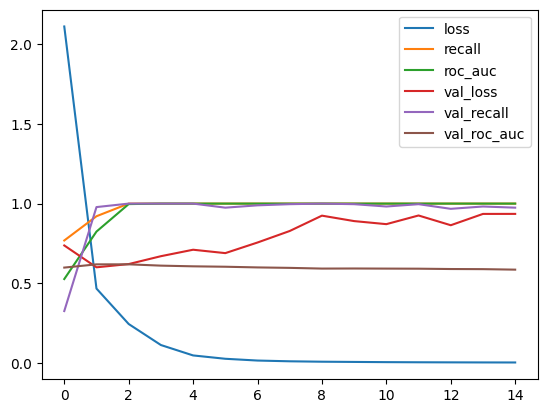

In [40]:
pd.DataFrame(opt_model2.history.history).plot()

In [83]:
opt_model2.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │       401,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,205,189 (4.60 MB)

 Trainable params: 401,729 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 803,460 (3.06 MB)

In [84]:
opt_model.save(f"Opt_Model_64.keras")

In [85]:
opt_model2.save(f"Opt_Model_32.keras")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


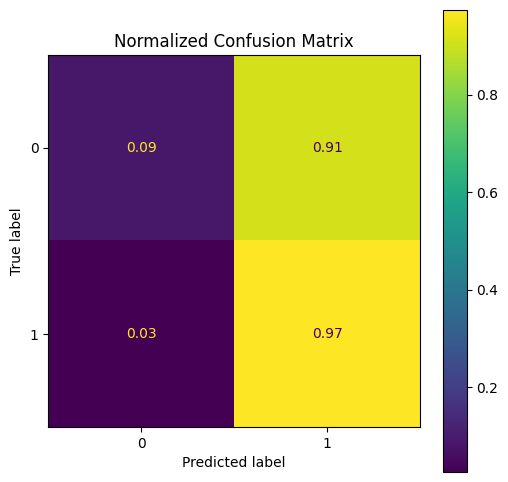

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = opt_model2.predict(X_val).ravel()
#y_prob = model.predict(X_val).ravel()
# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

In [50]:
Sums=[]
Hists=[]
Reports=[]
counter=-1
for par in pars:
    counter+=1
    # Compile
    model=create_model(*par)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='roc_auc')
        ]
    )
    
    # Capture summary lines
    summary_lines = []

    model.summary(print_fn=lambda x: summary_lines.append(x))

    # Convert to DataFrame
    df_summary = pd.DataFrame(summary_lines, columns=["model_summary"])
    Sums.append(df_summary)
    

    
    history = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=4,
        batch_size=32,
        verbose=0,
    
    )

    # Evaluation
    y_prob = model.predict(X_val).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    print("\nClassification Report:\n")
    cr=classification_report(y_val, y_pred)
    Reports.append(cr)
    print(cr)

    print("\nROC-AUC Score:")
    print(roc_auc_score(y_val, y_prob))
    Hists.append(history)
    model.save(f"Model_{counter}_mod.keras")

I0000 00:00:1778570757.192117   12624 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62318__.52
I0000 00:00:1778570761.572441   12624 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62318__.52


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       125
           1       0.69      1.00      0.81       274

    accuracy                           0.69       399
   macro avg       0.34      0.50      0.41       399
weighted avg       0.47      0.69      0.56       399


ROC-AUC Score:
0.5571678832116788


/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

I0000 00:00:1778570775.117162   12622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67436__.43
I0000 00:00:1778570778.254891   12622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67436__.43


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       125
           1       0.69      1.00      0.81       274

    accuracy                           0.69       399
   macro avg       0.34      0.50      0.41       399
weighted avg       0.47      0.69      0.56       399


ROC-AUC Score:
0.5855766423357665


/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.05      0.09       125
           1       0.69      0.96      0.80       274

    accuracy                           0.68       399
   macro avg       0.53      0.51      0.44       399
weighted avg       0.59      0.68      0.58       399


ROC-AUC Score:
0.6032408759124088


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       125
           1       0.69      1.00      0.81       274

    accuracy                           0.69       399
   macro avg       0.34      0.50      0.41       399
weighted avg       0.47      0.69      0.56       399


ROC-AUC Score:
0.5


/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danillo-souza/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

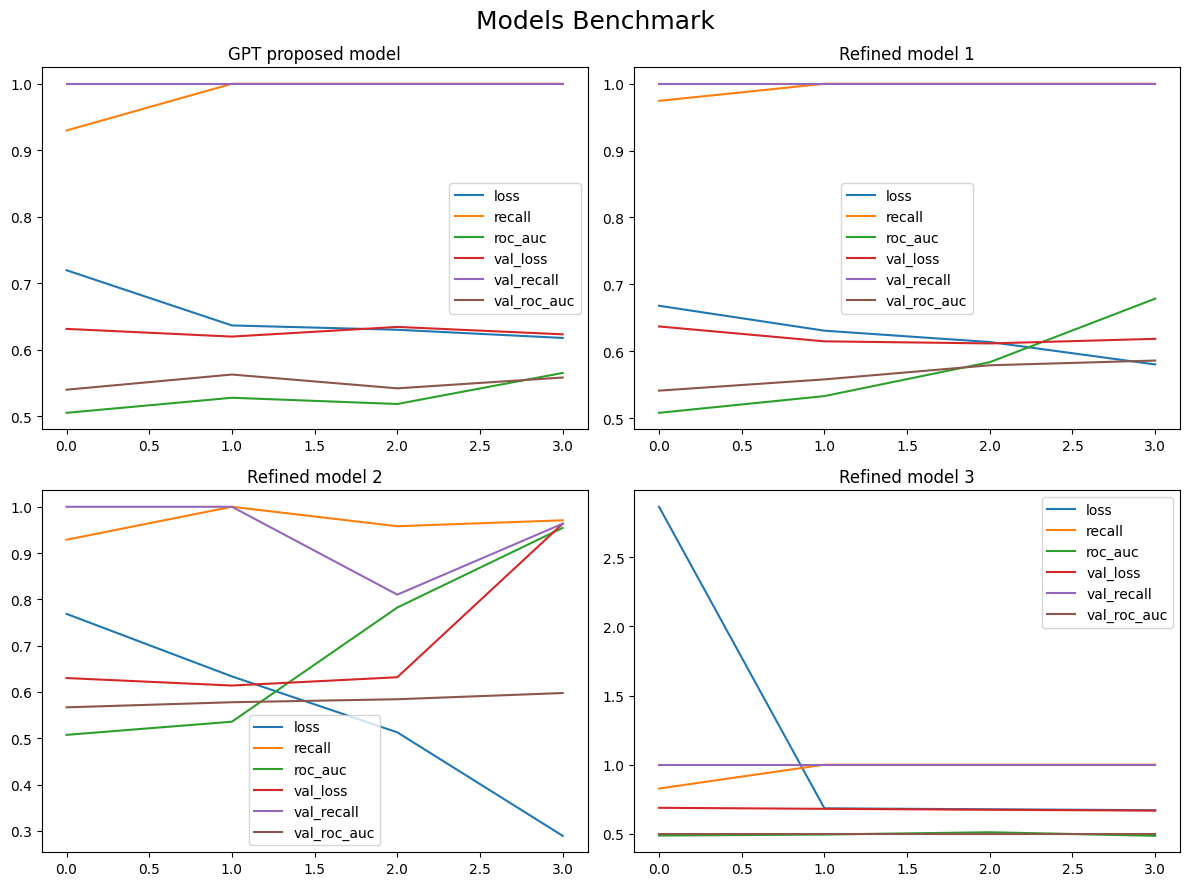

In [51]:

plt.figure(figsize=(12,9))
plt.suptitle("Models Benchmark",fontsize=18)
titles=["GPT proposed model", "Refined model 1", "Refined model 2", "Refined model 3"]
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    plt.title(titles[i])
    pd.DataFrame(Hists[i].history).plot(ax=ax)

plt.tight_layout()
plt.savefig("Image_Breast_Cancer_models_Benchmark_mod.png",dpi=150,bbox_inches="tight")

In [45]:
GPT_model = load_model("Model_0.keras")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


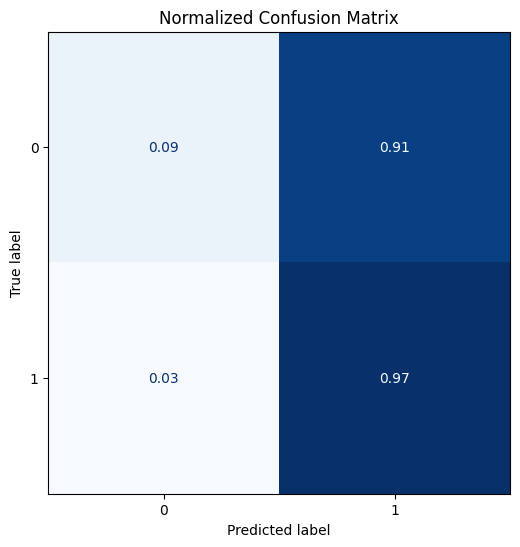

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = opt_model2.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

# Blue colormap and no colorbar
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


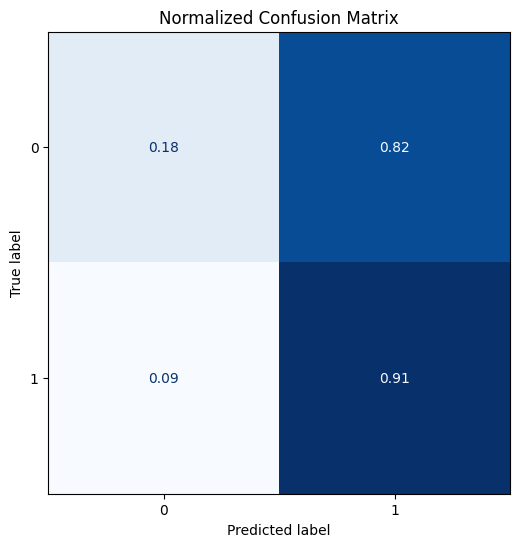

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = opt_model2.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

# Blue colormap and no colorbar
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


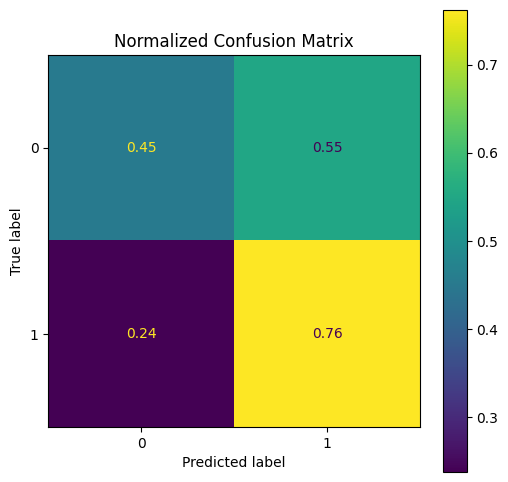

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = GPT_model.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

# WHY!?!?!

1. Inbalance between train classes;
2. Different dataset collection protocols

# What can we do?

1. Try to fix he inbalance in the model


In [44]:
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}

In [113]:
class_weight

{0: 1.64529262086514, 1: 0.7182848255943124}

In [114]:
# CNN model
opt_model3 = models.Sequential([

    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(1, activation='sigmoid')
])

# Compile
opt_model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='roc_auc')
    ]
)

# Train
history = opt_model3.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=0,
    class_weight=class_weight
    
)

# Evaluation
y_prob = opt_model3.predict(X_val).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_val, y_prob))


history = opt_model3.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=0,
    class_weight=class_weight
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       393
           1       0.99      1.00      0.99       901

    accuracy                           0.99      1294
   macro avg       0.99      0.99      0.99      1294
weighted avg       0.99      0.99      0.99      1294


ROC-AUC Score:
0.9995961512935867


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


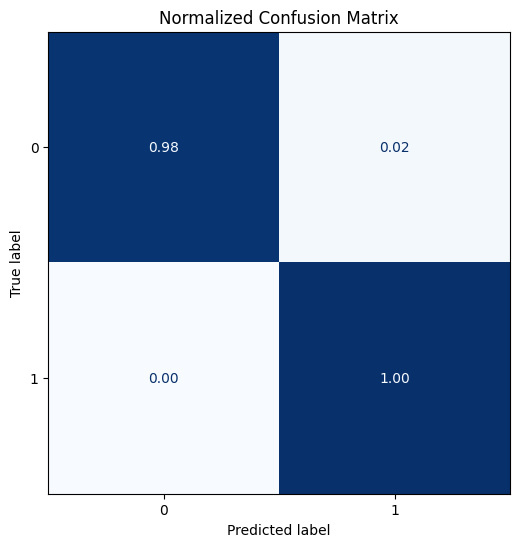

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = opt_model3.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

# Blue colormap and no colorbar
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


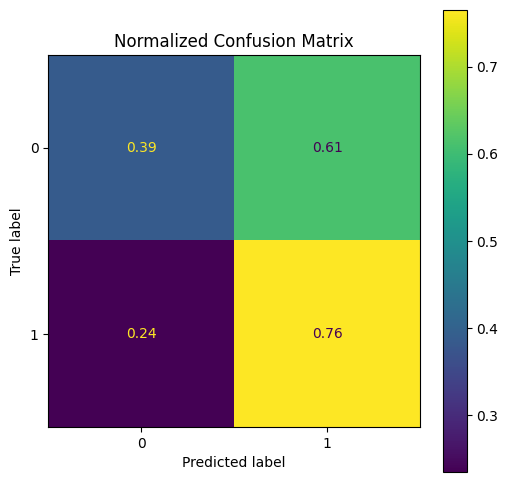

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = opt_model3.predict(outer_test).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_outer_test.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

 # It didn’t make things any better! :'(

### Another possible reason: 
* The imbalance in the train data that propagates through the detection of the benign class.
* An exploratory analysis is needed to verify why the model is classifying benign as malignant